# Black Friday Sales: fatores que influenciam compras premium

Este notebook utiliza o dataset público [Retail Black Friday Sales Dataset](https://www.kaggle.com/datasets/noopurbhatt/retail-black-friday-sales-dataset) para uma análise exploratória e constrói modelos de Machine Learning para responder:

**Quais fatores influenciam a probabilidade de um cliente realizar compras premium durante a Black Friday?**

>Definição operacional de compra premium
Como o dataset não traz uma coluna explícita indicando compra premium, este notebook define uma transação premium como aquela cujo valor de `purchase_amount` está no percentil 75 ou acima. Ou seja, compras no quartil superior de gasto são tratadas como premium.
Essa definição pode ser alterada na variável `PREMIUM_QUANTILE`.

## 1. Preparação

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="viridis")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

RANDOM_STATE = 42
PREMIUM_QUANTILE = 0.75
DATASET_SLUG = "noopurbhatt/retail-black-friday-sales-dataset"
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
DATA_DIR.mkdir(exist_ok=True)
FILE_NAME = "retail_black_friday_sales_100k.csv"

In [2]:
df_raw = pd.read_csv(DATA_DIR / FILE_NAME)
df_raw.head()

,transaction_id,customer_id,age_group,gender,city,customer_segment,product_id,product_category,original_price,discount_pct,final_price,quantity,purchase_amount,payment_method,purchase_date,purchase_hour,is_weekend,is_black_friday
0,T0000001,C007297,26-35,Male,San Francisco,Loyal,P2713,Footwear,153.730,35,99.920,1,99.920,Credit Card,2025-12-01,0,0,0
1,T0000002,C001640,56+,Other,Dallas,Returning,P7219,Beauty,230.050,40,138.030,1,138.030,PayPal,2025-11-24,5,0,0
2,T0000003,C018025,26-35,Male,Phoenix,New,P5521,Groceries,174.670,25,131.000,1,131.000,Credit Card,2025-11-24,14,0,0
3,T0000004,C016050,18-25,Other,Miami,VIP,P3003,Sports,399.610,40,239.770,1,239.770,Credit Card,2025-11-30,23,1,0
4,T0000005,C014629,46-55,Male,Los Angeles,Loyal,P4633,Footwear,120.870,30,84.610,2,169.220,Debit Card,2025-11-25,2,0,0


## 2. Entendimento inicial e qualidade dos dados

In [3]:
df = df_raw.copy()
df.columns = [column.strip() for column in df.columns]
display(df.info())
display(df.describe(include="all").T)

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    100000 non-null  str    
 1   customer_id       100000 non-null  str    
 2   age_group         100000 non-null  str    
 3   gender            100000 non-null  str    
 4   city              100000 non-null  str    
 5   customer_segment  100000 non-null  str    
 6   product_id        100000 non-null  str    
 7   product_category  100000 non-null  str    
 8   original_price    100000 non-null  float64
 9   discount_pct      100000 non-null  int64  
 10  final_price       100000 non-null  float64
 11  quantity          100000 non-null  int64  
 12  purchase_amount   100000 non-null  float64
 13  payment_method    100000 non-null  str    
 14  purchase_date     100000 non-null  str    
 15  purchase_hour     100000 non-null  int64  
 16  is_weekend        100000 non-nul

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,100000,100000,T0000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,100000,32997,C016694,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_group,100000,5,36-45,20145,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,100000,3,Female,33460,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,100000,10,New York,10105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_segment,100000,4,Returning,34946,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,100000,9000,P9694,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_category,100000,10,Accessories,10156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original_price,"100,000.000",NaN,NaN,NaN,330.282,444.316,5.000,88.118,180.220,333.712,"2,499.890"
discount_pct,"100,000.000",NaN,NaN,NaN,26.631,12.249,5.000,20.000,25.000,35.000,60.000


In [4]:
# tratar coluna de data
df["purchase_date"] = pd.to_datetime(df["purchase_date"], errors="coerce")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    100000 non-null  str           
 1   customer_id       100000 non-null  str           
 2   age_group         100000 non-null  str           
 3   gender            100000 non-null  str           
 4   city              100000 non-null  str           
 5   customer_segment  100000 non-null  str           
 6   product_id        100000 non-null  str           
 7   product_category  100000 non-null  str           
 8   original_price    100000 non-null  float64       
 9   discount_pct      100000 non-null  int64         
 10  final_price       100000 non-null  float64       
 11  quantity          100000 non-null  int64         
 12  purchase_amount   100000 non-null  float64       
 13  payment_method    100000 non-null  str           
 14  purchase_date   

In [5]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Variáveis numéricas:", numeric_columns)
print("Variáveis categóricas:", categorical_columns)

for column in categorical_columns:
    print(f"\n{column}: {df[column].nunique()} categorias")

Variáveis numéricas: ['original_price', 'discount_pct', 'final_price', 'quantity', 'purchase_amount', 'purchase_hour', 'is_weekend', 'is_black_friday']
Variáveis categóricas: ['transaction_id', 'customer_id', 'age_group', 'gender', 'city', 'customer_segment', 'product_id', 'product_category', 'payment_method', 'purchase_date']

transaction_id: 100000 categorias

customer_id: 32997 categorias

age_group: 5 categorias

gender: 3 categorias

city: 10 categorias

customer_segment: 4 categorias

product_id: 9000 categorias

product_category: 10 categorias

payment_method: 6 categorias

purchase_date: 8 categorias


In [6]:
### Procurar sinais iniciais de associação entre perfil do cliente, características do produto e valor de compra.

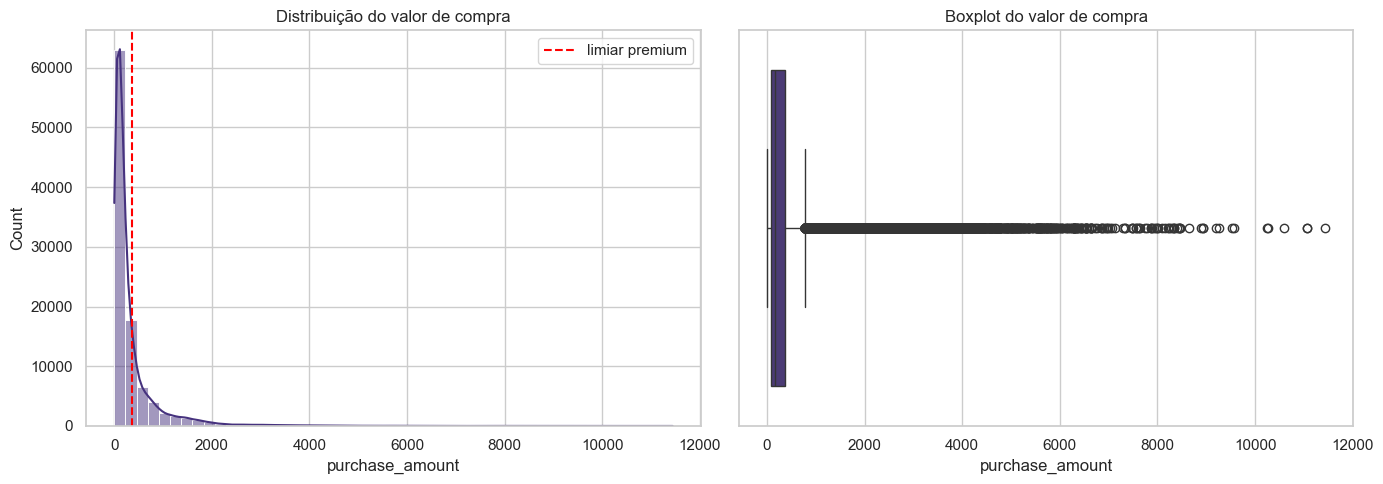

,purchase_amount
0.250,75.750
0.500,161.150
0.750,358.723
0.900,836.866
0.950,"1,379.128"
0.990,"3,003.746"


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["purchase_amount"], bins=50, kde=True, ax=axes[0])
axes[0].axvline(df["purchase_amount"].quantile(PREMIUM_QUANTILE), color="red", linestyle="--", label="limiar premium")
axes[0].set_title("Distribuição do valor de compra")
axes[0].legend()

sns.boxplot(x=df["purchase_amount"], ax=axes[1])
axes[1].set_title("Boxplot do valor de compra")

plt.tight_layout()
plt.show()

purchase_quantiles = df["purchase_amount"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
purchase_quantiles.to_frame("purchase_amount")

In [8]:
df["is_premium_purchase"] = (df["purchase_amount"] >= df["purchase_amount"].quantile(PREMIUM_QUANTILE)).astype(int)
premium_threshold = df["purchase_amount"].quantile(PREMIUM_QUANTILE)

print(f"Limiar de compra premium (P{int(PREMIUM_QUANTILE * 100)}): {premium_threshold:,.2f}")
print(f"Taxa de compras premium: {df['is_premium_purchase'].mean():.2%}")

df[["purchase_amount", "is_premium_purchase"]].head()

Limiar de compra premium (P75): 358.72
Taxa de compras premium: 25.00%


,purchase_amount,is_premium_purchase
0,99.920,0
1,138.030,0
2,131.000,0
3,239.770,0
4,169.220,0


,original_price,discount_pct,final_price,quantity,purchase_amount,purchase_hour,is_weekend,is_black_friday,is_premium_purchase
original_price,1.000,0.002,0.979,0.002,0.802,-0.000,0.003,-0.002,0.683
discount_pct,0.002,1.000,-0.119,0.003,-0.100,-0.006,-0.000,0.000,-0.096
final_price,0.979,-0.119,1.000,0.003,0.822,-0.000,0.003,-0.002,0.682
quantity,0.002,0.003,0.003,1.000,0.336,0.003,-0.002,-0.000,0.314
purchase_amount,0.802,-0.100,0.822,0.336,1.000,0.003,0.003,-0.003,0.643
purchase_hour,-0.000,-0.006,-0.000,0.003,0.003,1.000,0.004,0.002,-0.000
is_weekend,0.003,-0.000,0.003,-0.002,0.003,0.004,1.000,-0.218,-0.001
is_black_friday,-0.002,0.000,-0.002,-0.000,-0.003,0.002,-0.218,1.000,-0.001
is_premium_purchase,0.683,-0.096,0.682,0.314,0.643,-0.000,-0.001,-0.001,1.000


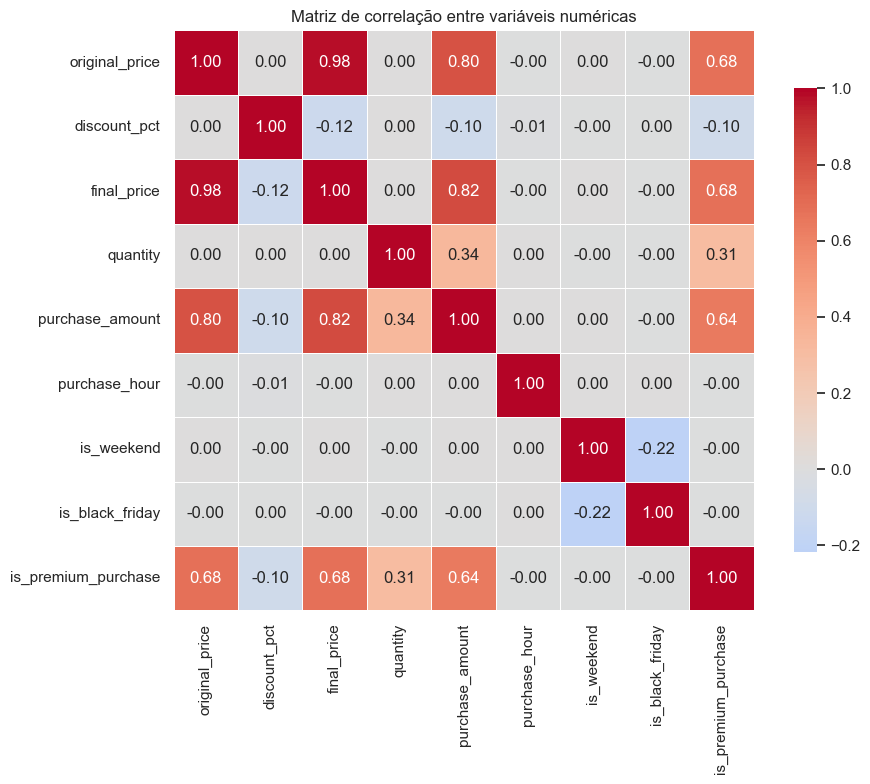

In [9]:
correlation_columns = [
    column
    for column in df.select_dtypes(include=np.number).columns
    if column not in ["transaction_id", "customer_id", "product_id"]
]

correlation_matrix = df[correlation_columns].corr()

display(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Matriz de correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

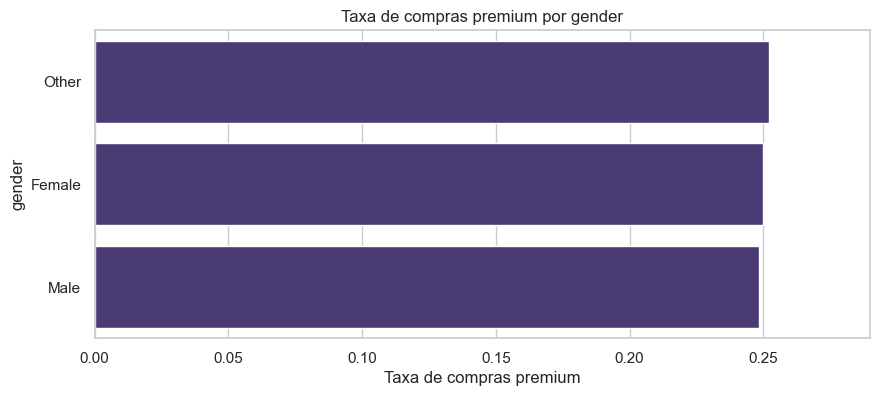

,premium_rate,avg_purchase,transactions
gender,,,
Other,0.252,353.591,33144
Female,0.250,347.846,33460
Male,0.248,352.356,33396


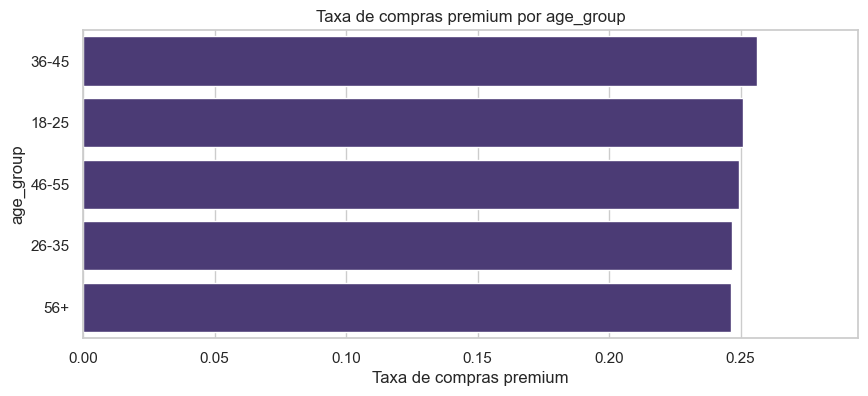

,premium_rate,avg_purchase,transactions
age_group,,,
36-45,0.256,357.254,20145
18-25,0.251,353.012,19974
46-55,0.250,350.469,20014
26-35,0.247,351.801,19960
56+,0.246,343.672,19907


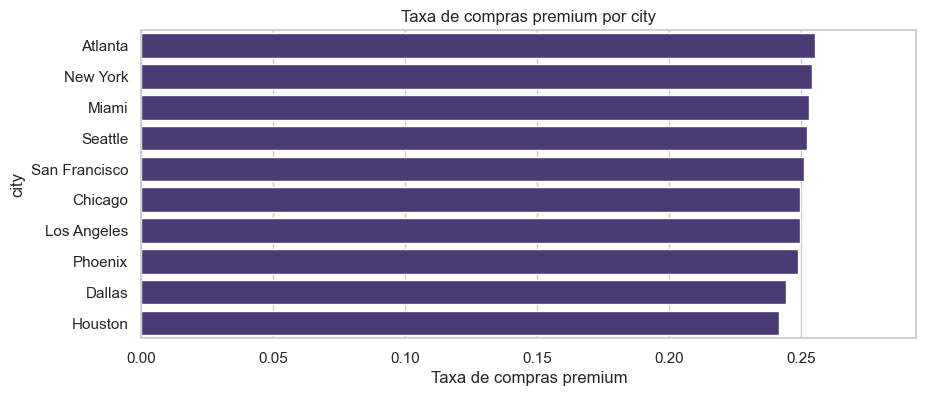

,premium_rate,avg_purchase,transactions
city,,,
Atlanta,0.255,359.141,10075
New York,0.254,350.965,10105
Miami,0.253,355.404,10036
Seattle,0.252,342.363,10097
San Francisco,0.251,345.644,9968
Chicago,0.250,352.859,9954
Los Angeles,0.250,352.962,9719
Phoenix,0.249,351.477,10032
Dallas,0.244,355.152,9990


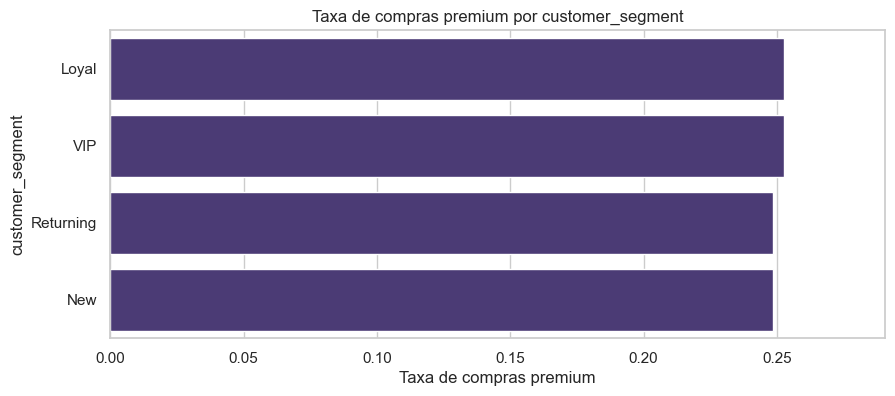

,premium_rate,avg_purchase,transactions
customer_segment,,,
Loyal,0.253,353.697,25130
VIP,0.253,354.862,9968
Returning,0.249,346.978,34946
New,0.248,352.999,29956


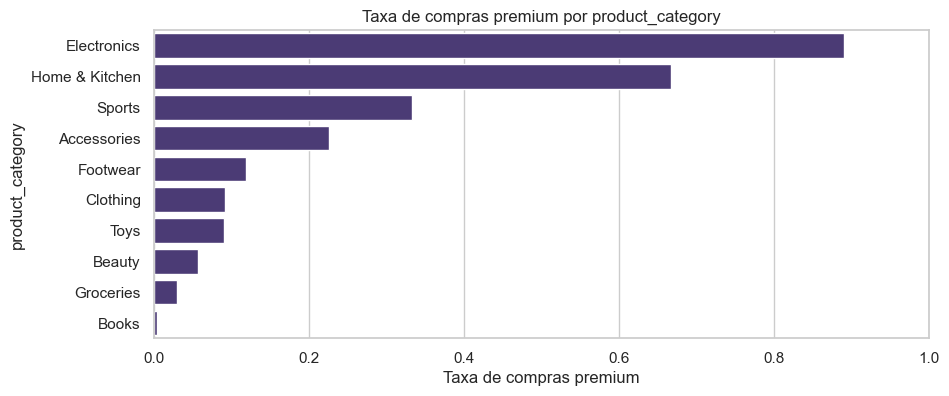

,premium_rate,avg_purchase,transactions
product_category,,,
Electronics,0.890,"1,416.026",9974
Home & Kitchen,0.667,653.561,9886
Sports,0.333,331.184,9975
Accessories,0.225,271.225,10156
Footwear,0.119,199.259,10104
Clothing,0.092,170.363,9911
Toys,0.091,166.024,10054
Beauty,0.057,137.696,9984
Groceries,0.030,108.412,9925


In [10]:
def plot_premium_rate_by(column: str, top_n: int | None = None) -> pd.DataFrame:
    summary = (
        df.groupby(column, dropna=False)
        .agg(
            premium_rate=("is_premium_purchase", "mean"),
            avg_purchase=("purchase_amount", "mean"),
            transactions=("purchase_amount", "size"),
        )
        .sort_values("premium_rate", ascending=False)
    )
    plot_data = summary.head(top_n) if top_n else summary

    plt.figure(figsize=(10, max(4, 0.35 * len(plot_data))))
    sns.barplot(data=plot_data.reset_index(), y=column, x="premium_rate", orient="h")
    plt.title(f"Taxa de compras premium por {column}")
    plt.xlabel("Taxa de compras premium")
    plt.ylabel(column)
    plt.xlim(0, min(1, plot_data["premium_rate"].max() * 1.15))
    plt.show()

    return summary

eda_dimensions = ["gender", "age_group", "city", "customer_segment", "product_category"]
for column in eda_dimensions:
    display(plot_premium_rate_by(column).head(20))

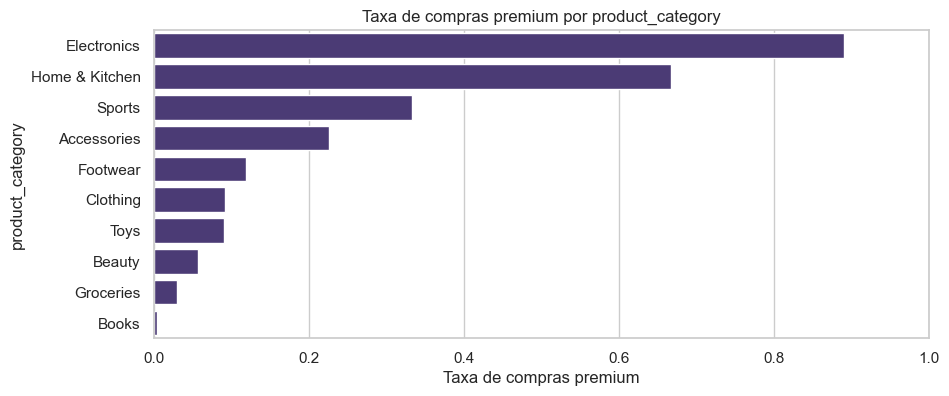

,premium_rate,avg_purchase,transactions
product_category,,,
Electronics,0.890,"1,416.026",9974
Home & Kitchen,0.667,653.561,9886
Sports,0.333,331.184,9975
Accessories,0.225,271.225,10156
Footwear,0.119,199.259,10104
Clothing,0.092,170.363,9911
Toys,0.091,166.024,10054
Beauty,0.057,137.696,9984
Groceries,0.030,108.412,9925


In [11]:
product_category_columns = [column for column in df.columns if column.startswith("product_category")]

for column in product_category_columns:
    if column in df.columns:
        display(plot_premium_rate_by(column, top_n=20).head(20))

## 3. Preparação para Machine Learning

A tarefa será tratada como classificação binária:

- `1`: transação premium (`purchase_amount` no percentil 75 ou acima);
- `0`: transação não premium.

Importante: `purchase_amount` não entra como variável explicativa, porque foi usado para construir o alvo. `customer_id`, `product_id`e `transaction_id` também são removidos para reduzir memorização de identificadores. O foco fica em atributos interpretáveis de cliente, cidade e produto.

In [12]:
target = "is_premium_purchase"
leakage_or_id_columns = ["purchase_amount", target, "customer_id", "product_id", "transaction_id"]
feature_columns = [column for column in df.columns if column not in leakage_or_id_columns]

X = df[feature_columns].copy()
y = df[target].copy()

# Mantém categorias de produto como categóricas, apesar de estarem codificadas numericamente.
category_like_columns = [column for column in X.columns if column in categorical_columns]
for column in category_like_columns:
    X[column] = X[column].astype("category")

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = [column for column in X.columns if column not in numeric_features]

print("Features numéricas:", numeric_features)
print("Features categóricas:", categorical_features)
print("Distribuição do alvo:")
display(y.value_counts(normalize=True).rename("proportion").to_frame())

Features numéricas: ['original_price', 'discount_pct', 'final_price', 'quantity', 'purchase_hour', 'is_weekend', 'is_black_friday']
Features categóricas: ['age_group', 'gender', 'city', 'customer_segment', 'product_category', 'payment_method', 'purchase_date']
Distribuição do alvo:


,proportion
is_premium_purchase,
0,0.750
1,0.250


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", encoder, categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

print(f"Treino: {X_train.shape}")
print(f"Teste: {X_test.shape}")

Treino: (80000, 14)
Teste: (20000, 14)


## 4. Modelagem

Serão comparados três modelos:

- Regressão Logística: baseline interpretável;
- Random Forest: modelo não linear com importância por impureza e permutação;
- HistGradientBoosting: modelo de boosting robusto para relações não lineares.

A métrica principal será **ROC AUC**, complementada por **Average Precision**, útil em problemas com classes desbalanceadas.

In [14]:
models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocess", preprocessor),
            (
                "model",
                LogisticRegression(
                    max_iter=2_000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocess", preprocessor),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=250,
                    min_samples_leaf=20,
                    class_weight="balanced_subsample",
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "HistGradientBoosting": Pipeline(
        steps=[
            ("preprocess", preprocessor),
            (
                "model",
                HistGradientBoostingClassifier(
                    learning_rate=0.08,
                    max_iter=250,
                    l2_regularization=0.01,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "accuracy": "accuracy",
}

cv_results = []
for name, pipeline in models.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )
    cv_results.append(
        {
            "model": name,
            "roc_auc_mean": scores["test_roc_auc"].mean(),
            "roc_auc_std": scores["test_roc_auc"].std(),
            "avg_precision_mean": scores["test_average_precision"].mean(),
            "accuracy_mean": scores["test_accuracy"].mean(),
        }
    )

cv_results_df = pd.DataFrame(cv_results).sort_values("roc_auc_mean", ascending=False)
cv_results_df

,model,roc_auc_mean,roc_auc_std,avg_precision_mean,accuracy_mean
2,HistGradientBoosting,1.000,0.000,1.000,0.999
1,Random Forest,1.000,0.000,1.000,0.998
0,Logistic Regression,0.995,0.000,0.985,0.960


Melhor modelo por validação cruzada: HistGradientBoosting
ROC AUC teste: 1.0000
Average Precision teste: 1.0000
Accuracy teste: 0.9984

Relatório de classificação:
              precision    recall  f1-score   support

 não premium       1.00      1.00      1.00     15000
     premium       1.00      1.00      1.00      5000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



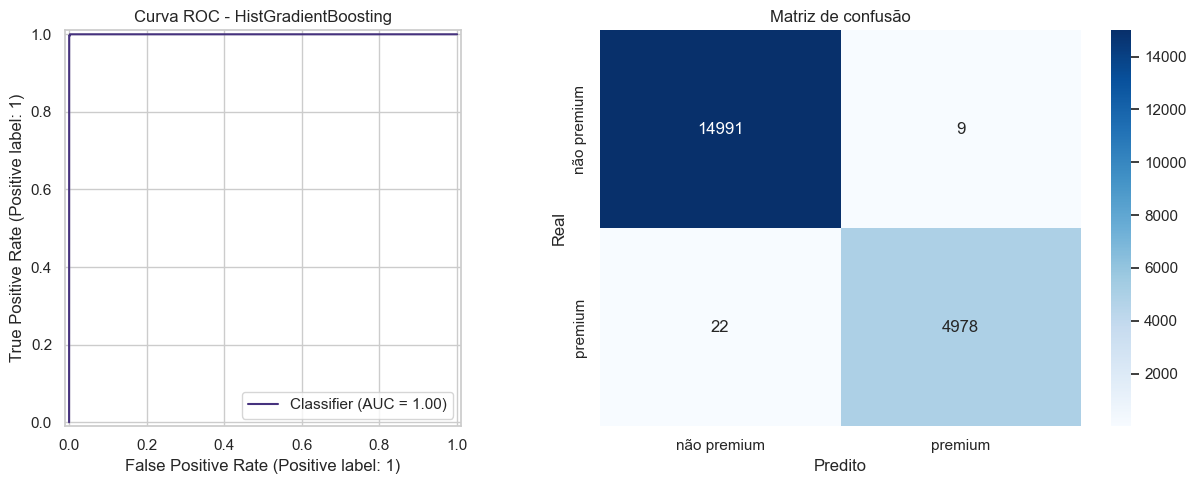

In [15]:
best_model_name = cv_results_df.iloc[0]["model"]
best_pipeline = models[best_model_name]
best_pipeline.fit(X_train, y_train)

if hasattr(best_pipeline.named_steps["model"], "predict_proba"):
    y_score = best_pipeline.predict_proba(X_test)[:, 1]
else:
    y_score = best_pipeline.decision_function(X_test)

y_pred = (y_score >= 0.5).astype(int)

print(f"Melhor modelo por validação cruzada: {best_model_name}")
print(f"ROC AUC teste: {roc_auc_score(y_test, y_score):.4f}")
print(f"Average Precision teste: {average_precision_score(y_test, y_score):.4f}")
print(f"Accuracy teste: {accuracy_score(y_test, y_pred):.4f}")
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred, target_names=["não premium", "premium"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
RocCurveDisplay.from_predictions(y_test, y_score, ax=axes[0])
axes[0].set_title(f"Curva ROC - {best_model_name}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Matriz de confusão")
axes[1].set_xlabel("Predito")
axes[1].set_ylabel("Real")
axes[1].set_xticklabels(["não premium", "premium"])
axes[1].set_yticklabels(["não premium", "premium"])

plt.tight_layout()
plt.show()

## 5. Feature Importance

A importância por permutação mede a queda de desempenho quando uma variável é embaralhada. Como ela é calculada sobre o pipeline completo, o resultado fica no nível das variáveis originais, o que facilita a interpretação de negócio.

,feature,importance_mean,importance_std
0,final_price,0.316,0.004
1,quantity,0.087,0.001
2,original_price,0.000,0.000
3,customer_segment,0.000,0.000
4,purchase_date,0.000,0.000
5,age_group,0.000,0.000
6,product_category,0.000,0.000
7,discount_pct,0.000,0.000
8,gender,0.000,0.000
9,payment_method,-0.000,0.000


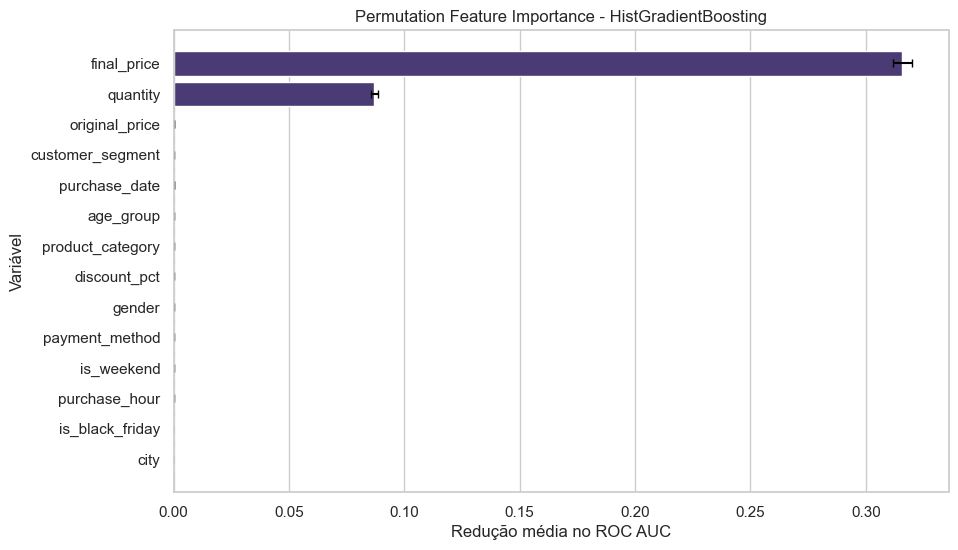

In [16]:
permutation = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

permutation_importance_df = (
    pd.DataFrame(
        {
            "feature": X_test.columns,
            "importance_mean": permutation.importances_mean,
            "importance_std": permutation.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(permutation_importance_df)

permutation_top15 = permutation_importance_df.head(15)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=permutation_top15,
    x="importance_mean",
    y="feature",
)
ax.errorbar(
    x=permutation_top15["importance_mean"],
    y=np.arange(len(permutation_top15)),
    xerr=permutation_top15["importance_std"],
    fmt="none",
    color="black",
    capsize=3,
)
plt.title(f"Permutation Feature Importance - {best_model_name}")
plt.xlabel("Redução média no ROC AUC")
plt.ylabel("Variável")
plt.show()

In [17]:
def get_transformed_feature_names(pipeline: Pipeline) -> list[str]:
    transformer = pipeline.named_steps["preprocess"]
    try:
        return transformer.get_feature_names_out().tolist()
    except Exception:
        names = []
        if numeric_features:
            names.extend(numeric_features)
        if categorical_features:
            encoder_step = transformer.named_transformers_["cat"]
            names.extend(encoder_step.get_feature_names_out(categorical_features).tolist())
        return names

transformed_feature_names = get_transformed_feature_names(best_pipeline)
model = best_pipeline.named_steps["model"]

if hasattr(model, "feature_importances_"):
    model_importance_df = (
        pd.DataFrame(
            {
                "feature": transformed_feature_names,
                "importance": model.feature_importances_,
            }
        )
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    display(model_importance_df.head(25))

    plt.figure(figsize=(10, 7))
    sns.barplot(data=model_importance_df.head(20), x="importance", y="feature")
    plt.title(f"Importância interna do modelo - {best_model_name}")
    plt.xlabel("Importância")
    plt.ylabel("Variável transformada")
    plt.show()
elif hasattr(model, "coef_"):
    coef_df = (
        pd.DataFrame(
            {
                "feature": transformed_feature_names,
                "coefficient": model.coef_[0],
                "abs_coefficient": np.abs(model.coef_[0]),
            }
        )
        .sort_values("abs_coefficient", ascending=False)
        .reset_index(drop=True)
    )
    display(coef_df.head(25))

    plt.figure(figsize=(10, 7))
    sns.barplot(data=coef_df.head(20), x="coefficient", y="feature")
    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"Coeficientes mais relevantes - {best_model_name}")
    plt.xlabel("Coeficiente")
    plt.ylabel("Variável transformada")
    plt.show()
else:
    print("O modelo selecionado não expõe importância interna direta. Use a importância por permutação acima.")

O modelo selecionado não expõe importância interna direta. Use a importância por permutação acima.


## 6. SHAP e Explainable AI

SHAP estima quanto cada variável contribui para deslocar a previsão em direção à classe premium ou não premium. A análise abaixo usa uma amostra do conjunto de teste para manter o tempo de execução controlado.

Interpretação geral:

- valores SHAP positivos aumentam a probabilidade estimada de compra premium;
- valores SHAP negativos reduzem a probabilidade estimada de compra premium;
- a magnitude indica força da contribuição.

In [18]:
import shap

sample_size = min(2_000, len(X_test))
background_size = min(500, len(X_train))

X_train_sample = X_train.sample(background_size, random_state=RANDOM_STATE)
X_test_sample = X_test.sample(sample_size, random_state=RANDOM_STATE)

preprocess_fitted = best_pipeline.named_steps["preprocess"]
model_fitted = best_pipeline.named_steps["model"]

X_train_transformed = preprocess_fitted.transform(X_train_sample)
X_test_transformed = preprocess_fitted.transform(X_test_sample)

if not isinstance(X_train_transformed, np.ndarray):
    X_train_transformed = X_train_transformed.toarray()
if not isinstance(X_test_transformed, np.ndarray):
    X_test_transformed = X_test_transformed.toarray()

X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=transformed_feature_names, index=X_train_sample.index)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=transformed_feature_names, index=X_test_sample.index)

if isinstance(model_fitted, LogisticRegression):
    explainer = shap.LinearExplainer(model_fitted, X_train_transformed_df)
elif isinstance(model_fitted, (RandomForestClassifier, HistGradientBoostingClassifier)):
    explainer = shap.TreeExplainer(model_fitted)
else:
    explainer = shap.Explainer(model_fitted.predict_proba, X_train_transformed_df)

shap_values = explainer(X_test_transformed_df)
shap_values

.values =
array([[ 2.78945042e-01, -8.87998771e-03,  1.26323426e+01, ...,
        -1.31804512e-04, -2.19142585e-03,  1.64912969e-04],
       [-4.03790008e-02, -1.86608121e-02, -4.05278568e+00, ...,
        -1.06530772e-04,  6.12738071e-02,  6.03183039e-05],
       [-5.51755998e-02,  5.03059598e-03, -3.03119732e+00, ...,
        -2.25531052e-05, -1.21202424e-02,  5.83651507e-05],
       ...,
       [-3.99086298e-02, -1.16697536e-02, -3.52158077e+00, ...,
        -6.04849642e-05, -1.89049432e-02,  6.11462957e-05],
       [-5.08276632e-02,  6.93236407e-03, -3.98351123e+00, ...,
        -5.75454380e-05, -7.04073042e-03,  5.80333613e-05],
       [-4.60698838e-02,  6.38385393e-03, -3.52639701e+00, ...,
         6.53083103e-04, -1.95828535e-02,  6.03183039e-05]],
      shape=(2000, 53))

.base_values =
array([-5.06435139, -5.06435139, -5.06435139, ..., -5.06435139,
       -5.06435139, -5.06435139], shape=(2000,))

.data =
array([[ 4.16473647,  1.90520298,  2.5488192 , ...,  0.        ,
      

In [19]:
def positive_class_shap_explanation(explanation: shap.Explanation) -> shap.Explanation:
    """Normaliza a saída do SHAP para explicar a classe premium."""
    values = explanation.values
    base_values = explanation.base_values
    data = explanation.data

    if values.ndim == 3:
        # Formato comum em classificadores: amostras x features x classes.
        if values.shape[-1] == 2:
            values = values[:, :, 1]
            if np.asarray(base_values).ndim == 2:
                base_values = base_values[:, 1]
        # Fallback para formato amostras x classes x features.
        elif values.shape[1] == 2:
            values = values[:, 1, :]
            if np.asarray(base_values).ndim == 2:
                base_values = base_values[:, 1]

    return shap.Explanation(
        values=values,
        base_values=base_values,
        data=data,
        feature_names=explanation.feature_names,
    )

shap_positive = positive_class_shap_explanation(shap_values)
print(f"Formato dos valores SHAP da classe premium: {shap_positive.values.shape}")

Formato dos valores SHAP da classe premium: (2000, 53)


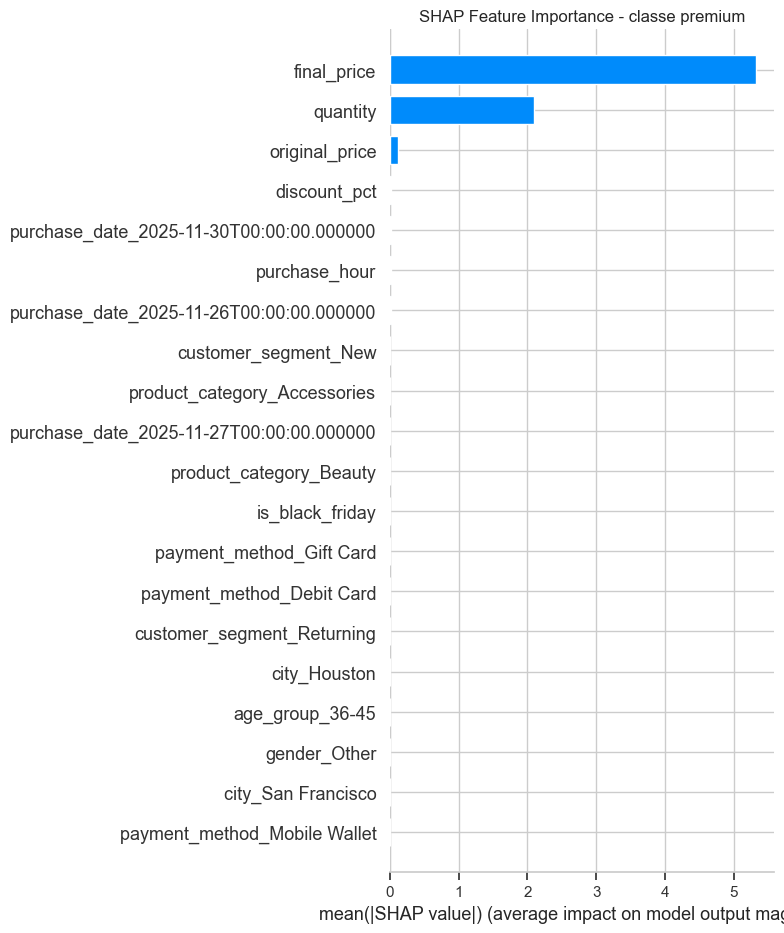

In [20]:
shap.summary_plot(
    shap_positive.values,
    X_test_transformed_df,
    feature_names=transformed_feature_names,
    plot_type="bar",
    max_display=20,
    show=False,
)
plt.title("SHAP Feature Importance - classe premium")
plt.tight_layout()
plt.show()


,original_feature,mean_abs_shap
0,final_price,5.315
1,quantity,2.100
2,original_price,0.121
3,purchase_date,0.049
4,product_category,0.030
5,discount_pct,0.025
6,customer_segment,0.021
7,purchase_hour,0.021
8,city,0.019
9,payment_method,0.017


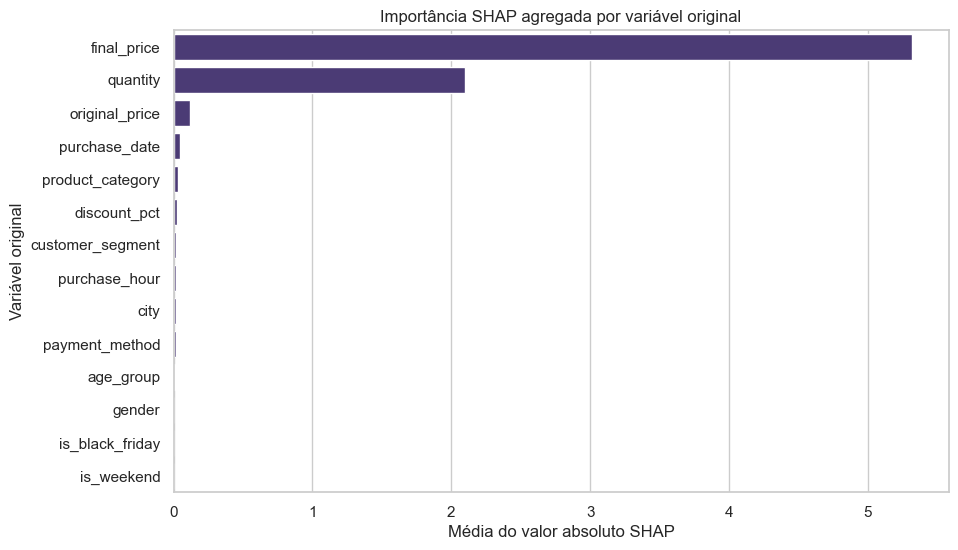

In [21]:
def map_transformed_to_original_feature(transformed_feature: str) -> str:
    if transformed_feature in numeric_features:
        return transformed_feature

    matching_categorical = [
        feature for feature in categorical_features if transformed_feature.startswith(f"{feature}_")
    ]
    if matching_categorical:
        return max(matching_categorical, key=len)

    return transformed_feature

shap_importance_original_df = (
    pd.DataFrame(
        {
            "transformed_feature": transformed_feature_names,
            "original_feature": [map_transformed_to_original_feature(feature) for feature in transformed_feature_names],
            "mean_abs_shap": np.abs(shap_positive.values).mean(axis=0),
        }
    )
    .groupby("original_feature", as_index=False)["mean_abs_shap"]
    .sum()
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(shap_importance_original_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=shap_importance_original_df.head(15), x="mean_abs_shap", y="original_feature")
plt.title("Importância SHAP agregada por variável original")
plt.xlabel("Média do valor absoluto SHAP")
plt.ylabel("Variável original")
plt.show()